In [ ]:
# The code chunk below is to report the memory required to train the resnet50 through SGD using GPU
# The memory required for batch-size 8 is 0.94 GB

In [2]:
# import torch
# import torchvision.models as models

# device = torch.device('cuda:0'if torch.cuda.is_available() else 'cpu')

# def print_allocated_memory():
#     print("{:.2f} GB".format(torch.cuda.memory_allocated() / 1024 ** 3))

# resnet50_input = torch.ones(8, 3, 256, 256).float().to(device)

# resnet50 = models.resnet50(pretrained = False).to(device)

# # for param in resnet50.parameters():
# #     param.requires_grad = False

# encoded = resnet50(resnet50_input)

# print_allocated_memory()

0.94 GB


In [1]:
import pyreadr
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import time
from lifelines.utils import concordance_index
from matplotlib import pyplot as plt

device = torch.device('cuda:0'if torch.cuda.is_available() else 'cpu')

In [2]:
# Load local defined functions
from func_acc import loss_CoxPH

In [3]:
img_feature = []
demo_feature = ['enrollage','high_school','smoke_current','smoke_former']
x_img_demo = img_feature+demo_feature
feature_tobe_scaled = ['enrollage']

feature_tobe_scaled_index = np.array([x_img_demo.index(f) for f in feature_tobe_scaled]).reshape(-1)

df_train = pyreadr.read_r('AMDprediction/Data/start_stop_working.Rdata')['df_working']
df_test = pyreadr.read_r('AMDprediction/Data/start_stop_test.Rdata')['df_test']

index_train_list = df_train.index[df_train['tstart'] == 0].tolist()
index_test_list = df_test.index[df_test['tstart'] == 0].tolist()

df_train_base = df_train.iloc[index_train_list]
df_test_base = df_test.iloc[index_test_list]

In [4]:
# xxxx
x = np.load("Data/AREDS1_image/x_train_demo_scaled_7087.npy")
x_test0 = np.load("Data/AREDS1_image/x_test_demo_scaled_778.npy")
x_img_train_base = np.load("Data/AREDS1_image/img_train_base_7087.npy")
x_img_test_base0 = np.load("Data/AREDS1_image/img_test_base_778.npy")

# yyyy
y = df_train_base[['tstart','tstop_final','event_final']]
y_test0 = df_test_base[['tstart','tstop_final','event_final']]

x_img_test_base = torch.from_numpy(x_img_test_base0.astype(np.float32)).permute(0,3,1,2).to(device)
x_test = torch.from_numpy(x_test0.astype(np.float32)).to(device)
y_test = torch.from_numpy(y_test0.to_numpy().astype(np.float32)).to(device)

In [5]:
class CoxSNN(nn.Module):
    def __init__(self,num_nodes,num_dr,freeze_resnet50 = False):
        super(CoxSNN, self).__init__()
        self.cnn = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

        if freeze_resnet50:
            for param in self.cnn.parameters():
                param.requires_grad = False
        
        self.cnn.fc = nn.Linear(self.cnn.fc.in_features, 10)
        
        self.fc1 = nn.Linear(10+4, num_nodes)
        self.batchnorm = nn.BatchNorm1d(num_nodes)
        self.dropout = nn.Dropout(p=num_dr)
        self.fc2 = nn.Linear(num_nodes, 1, bias=False)
        
        
    def forward(self, image, demo):
        resnet_features = self.cnn(image)
        x = torch.cat((resnet_features, demo), dim=1)
        x = self.fc1(x)
        x = self.batchnorm(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [6]:
# # Fix the initial weight
# initial_weight_node32 = CoxSNN(32,0.2,True)
# torch.save(initial_weight_node32.state_dict(), 'initial_weight_node32.pth')

In [7]:
# Convert data to torch tensors
class Data(Dataset):
    def __init__(self, img, demo, y):
        self.img = torch.from_numpy(img.astype(np.float32)).permute(0,3,1,2).to(device)
        self.demo = torch.from_numpy(demo.astype(np.float32)).to(device)
        self.y = torch.from_numpy(y.to_numpy().astype(np.float32)).to(device)
        self.len = self.demo.shape[0]
       
    def __getitem__(self, index):
        return self.img[index], self.demo[index], self.y[index]
   
    def __len__(self):
        return self.len

In [8]:
class Train_CoxSNN_32node:
    def __init__(self,
                 num_lr,
                 num_dr,
                 num_epoch,
                 batch_size,
                 device,
                 freeze_resnet50,
                 torchseed = 133233):
        ### set up DNN parameters ###
        self.num_nodes = 32             # number of nodes per hidden layer
        self.num_lr = num_lr             # learning rate
        self.num_dr = num_dr              # dropout rate
        self.num_epoch = num_epoch             # number of epoches for optimization
        self.batch_size = batch_size            # number of batch size for optimization
        self.device = device
        CoxNN = CoxSNN(self.num_nodes,num_dr,freeze_resnet50)
        CoxNN.load_state_dict(torch.load('initial_weight_node32.pth'))
        self.CoxNN = CoxNN.to(device)
        self.loss_fn = loss_CoxPH
        self.optimizer = torch.optim.SGD(self.CoxNN.parameters(), lr=num_lr)
        # Instantiate training and test data
        train_data = Data(x_img_train_base, x, y)
        self.train_dataloader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)
        self.torchseed = torchseed

    def fit(self):
        torch.manual_seed(self.torchseed)
        epoch_loss = []
        epoch_test_loss = []
        epoch_cindex = []
        epoch_time = []
        with torch.no_grad():
            test_outputs = self.CoxNN(x_img_test_base, x_test)
            test_loss = self.loss_fn(test_outputs, y_test, self.device)
            epoch_test_loss.append(test_loss.item())
            cindex = concordance_index(y_test0["tstop_final"].to_numpy(),
                                       -test_outputs.cpu().detach().numpy(),
                                       y_test0["event_final"].to_numpy())
            epoch_cindex.append(cindex)
            
        for epoch in range(self.num_epoch):
            running_loss = 0.0
            t0 = time.time()
            for i, data in enumerate(self.train_dataloader):
                img_tmp, demo_tmp, y_tmp = data
                self.optimizer.zero_grad()
                outputs = self.CoxNN(img_tmp, demo_tmp)
                loss = self.loss_fn(outputs, y_tmp, device)
                if loss != torch.tensor(0.):
                    loss.backward()
                self.optimizer.step()
                running_loss += loss.item()
            epoch_loss.append(running_loss / (i+1))
        
            with torch.no_grad():
                test_outputs = self.CoxNN(x_img_test_base, x_test)
                test_loss = self.loss_fn(test_outputs, y_test, self.device)
                epoch_test_loss.append(test_loss.item())
                cindex = concordance_index(y_test0["tstop_final"].to_numpy(),
                                           -test_outputs.cpu().detach().numpy(),
                                           y_test0["event_final"].to_numpy())
                epoch_cindex.append(cindex)
        
            epoch_time_running = time.time() - t0
            epoch_time.append(epoch_time_running)
            print(f'[{epoch + 1:3d}/ {self.num_epoch:3d}] loss: {running_loss / (i+1):.5f} val_loss: {test_loss: .5f} c-index: {cindex: .5f} time: {epoch_time_running:.5f} seconds')
        print("Training Complete")
        self.epoch_loss = epoch_loss
        self.epoch_test_loss = epoch_test_loss
        self.epoch_cindex = epoch_cindex
        self.epoch_time = epoch_time

In [11]:
fit_lr002_s64 = Train_CoxSNN_32node(num_lr = 0.002,num_dr = 0.3,num_epoch = 30,batch_size = 64,device = device,freeze_resnet50 = False)
fit_lr002_s64.fit()
torch.cuda.empty_cache()

[  1/  30] loss: 0.77698 val_loss:  1.39159 c-index:  0.57602 time: 11.29146 seconds
[  2/  30] loss: 0.76223 val_loss:  1.37649 c-index:  0.62808 time: 11.04325 seconds
[  3/  30] loss: 0.75059 val_loss:  1.37617 c-index:  0.63595 time: 11.04237 seconds
[  4/  30] loss: 0.73824 val_loss:  1.36734 c-index:  0.64496 time: 11.04315 seconds
[  5/  30] loss: 0.71950 val_loss:  1.34611 c-index:  0.69195 time: 11.04365 seconds
[  6/  30] loss: 0.69992 val_loss:  1.32785 c-index:  0.73240 time: 11.04369 seconds
[  7/  30] loss: 0.67923 val_loss:  1.30081 c-index:  0.76625 time: 11.04510 seconds
[  8/  30] loss: 0.66046 val_loss:  1.29568 c-index:  0.77592 time: 11.04370 seconds
[  9/  30] loss: 0.64118 val_loss:  1.27071 c-index:  0.79503 time: 11.04241 seconds
[ 10/  30] loss: 0.62513 val_loss:  1.28206 c-index:  0.79333 time: 11.04321 seconds
[ 11/  30] loss: 0.61301 val_loss:  1.26893 c-index:  0.80713 time: 11.04414 seconds
[ 12/  30] loss: 0.60150 val_loss:  1.25155 c-index:  0.82335 tim

In [12]:
fit_lr002_s32 = Train_CoxSNN_32node(num_lr = 0.002,num_dr = 0.3,num_epoch = 30,batch_size = 32,device = device,freeze_resnet50 = False)
fit_lr002_s32.fit()
torch.cuda.empty_cache()

[  1/  30] loss: 0.63288 val_loss:  1.38462 c-index:  0.60642 time: 9.82731 seconds
[  2/  30] loss: 0.60767 val_loss:  1.36037 c-index:  0.68509 time: 9.82662 seconds
[  3/  30] loss: 0.57975 val_loss:  1.33112 c-index:  0.72943 time: 9.82799 seconds
[  4/  30] loss: 0.53802 val_loss:  1.28189 c-index:  0.79618 time: 9.82802 seconds
[  5/  30] loss: 0.50871 val_loss:  1.27454 c-index:  0.80288 time: 9.82738 seconds
[  6/  30] loss: 0.48574 val_loss:  1.24817 c-index:  0.82875 time: 9.79861 seconds
[  7/  30] loss: 0.47437 val_loss:  1.24865 c-index:  0.82038 time: 9.83003 seconds
[  8/  30] loss: 0.46883 val_loss:  1.23655 c-index:  0.83013 time: 9.83041 seconds
[  9/  30] loss: 0.44667 val_loss:  1.24110 c-index:  0.83269 time: 9.83264 seconds
[ 10/  30] loss: 0.43513 val_loss:  1.23291 c-index:  0.83744 time: 9.83109 seconds
[ 11/  30] loss: 0.42479 val_loss:  1.23706 c-index:  0.83166 time: 9.83121 seconds
[ 12/  30] loss: 0.41333 val_loss:  1.23651 c-index:  0.83954 time: 9.80178 

In [10]:
fit_lr001_s32 = Train_CoxSNN_32node(num_lr = 0.001,num_dr = 0.3,num_epoch = 30,batch_size = 32,device = device,freeze_resnet50 = False)
fit_lr001_s32.fit()
torch.cuda.empty_cache()

[  1/  30] loss: 0.63738 val_loss:  1.39585 c-index:  0.56493 time: 11.61470 seconds
[  2/  30] loss: 0.62221 val_loss:  1.38310 c-index:  0.61134 time: 9.79753 seconds
[  3/  30] loss: 0.61220 val_loss:  1.37831 c-index:  0.61289 time: 9.79995 seconds
[  4/  30] loss: 0.59546 val_loss:  1.34715 c-index:  0.70296 time: 9.80354 seconds
[  5/  30] loss: 0.58162 val_loss:  1.34650 c-index:  0.70023 time: 9.80612 seconds
[  6/  30] loss: 0.56241 val_loss:  1.31981 c-index:  0.75448 time: 9.78048 seconds
[  7/  30] loss: 0.54042 val_loss:  1.30609 c-index:  0.76375 time: 9.81295 seconds
[  8/  30] loss: 0.52577 val_loss:  1.29644 c-index:  0.77992 time: 9.81785 seconds
[  9/  30] loss: 0.50551 val_loss:  1.29515 c-index:  0.78694 time: 9.82005 seconds
[ 10/  30] loss: 0.49519 val_loss:  1.28855 c-index:  0.79524 time: 9.82243 seconds
[ 11/  30] loss: 0.48544 val_loss:  1.27303 c-index:  0.80757 time: 9.82652 seconds
[ 12/  30] loss: 0.47359 val_loss:  1.27002 c-index:  0.81941 time: 9.79867

In [13]:
fit_lr001_s64 = Train_CoxSNN_32node(num_lr = 0.001,num_dr = 0.3,num_epoch = 30,batch_size = 64,device = device,freeze_resnet50 = False)
fit_lr001_s64.fit()
torch.cuda.empty_cache()

[  1/  30] loss: 0.78056 val_loss:  1.39766 c-index:  0.55802 time: 11.04667 seconds
[  2/  30] loss: 0.77085 val_loss:  1.38876 c-index:  0.59324 time: 11.04675 seconds
[  3/  30] loss: 0.76308 val_loss:  1.39186 c-index:  0.58222 time: 11.04649 seconds
[  4/  30] loss: 0.75940 val_loss:  1.39200 c-index:  0.57173 time: 11.04583 seconds
[  5/  30] loss: 0.75031 val_loss:  1.38017 c-index:  0.61527 time: 11.04767 seconds
[  6/  30] loss: 0.74069 val_loss:  1.36980 c-index:  0.66232 time: 11.04837 seconds
[  7/  30] loss: 0.73537 val_loss:  1.36264 c-index:  0.67285 time: 11.04821 seconds
[  8/  30] loss: 0.72768 val_loss:  1.35036 c-index:  0.69203 time: 11.04743 seconds
[  9/  30] loss: 0.71664 val_loss:  1.34391 c-index:  0.70320 time: 11.04881 seconds
[ 10/  30] loss: 0.70365 val_loss:  1.34390 c-index:  0.70296 time: 11.04712 seconds
[ 11/  30] loss: 0.69570 val_loss:  1.33272 c-index:  0.71401 time: 11.04832 seconds
[ 12/  30] loss: 0.68430 val_loss:  1.31245 c-index:  0.75729 tim

In [17]:
fit_lr004_s64 = Train_CoxSNN_32node(num_lr = 0.004,num_dr = 0.3,num_epoch = 30,batch_size = 64,device = device,freeze_resnet50 = False)
fit_lr004_s64.fit()
torch.cuda.empty_cache()

[  1/  30] loss: 0.76992 val_loss:  1.38051 c-index:  0.61414 time: 11.01512 seconds
[  2/  30] loss: 0.73996 val_loss:  1.35184 c-index:  0.69289 time: 11.02003 seconds
[  3/  30] loss: 0.70383 val_loss:  1.32016 c-index:  0.74507 time: 11.02522 seconds
[  4/  30] loss: 0.66827 val_loss:  1.30316 c-index:  0.76559 time: 11.02921 seconds
[  5/  30] loss: 0.63194 val_loss:  1.26538 c-index:  0.80785 time: 11.03541 seconds
[  6/  30] loss: 0.60870 val_loss:  1.25764 c-index:  0.82039 time: 11.03835 seconds
[  7/  30] loss: 0.58916 val_loss:  1.23990 c-index:  0.83119 time: 11.04057 seconds
[  8/  30] loss: 0.57319 val_loss:  1.24096 c-index:  0.83620 time: 11.04367 seconds
[  9/  30] loss: 0.54929 val_loss:  1.23981 c-index:  0.83545 time: 11.04412 seconds
[ 10/  30] loss: 0.53270 val_loss:  1.25735 c-index:  0.82897 time: 11.04623 seconds
[ 11/  30] loss: 0.51994 val_loss:  1.25117 c-index:  0.83426 time: 11.04684 seconds
[ 12/  30] loss: 0.49432 val_loss:  1.29724 c-index:  0.82942 tim

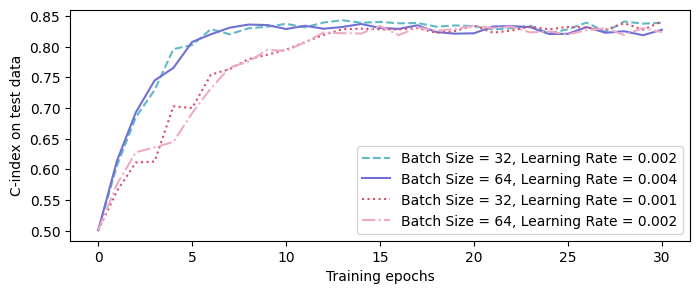

In [39]:
plt.figure(figsize=(8, 3))
plt.ylabel('C-index on test data')
plt.xlabel('Training epochs')
plt.plot(fit_lr002_s32.epoch_cindex,ls = '--', label='Batch Size = 32, Learning Rate = 0.002', color="#61B8C9")
plt.plot(fit_lr004_s64.epoch_cindex,ls = '-', label='Batch Size = 64, Learning Rate = 0.004', color="#7070D5")
plt.plot(fit_lr001_s32.epoch_cindex,ls = ':', label='Batch Size = 32, Learning Rate = 0.001', color="#d94c66")
plt.plot(fit_lr002_s64.epoch_cindex,ls = '-.', label='Batch Size = 64, Learning Rate = 0.002', color="#EFAAC7")
plt.legend()
plt.show
plt.savefig('Figure/AREDS_CoxSNN_cindex.png',bbox_inches='tight', dpi=300)

In [10]:
fit_lr002_s32 = Train_CoxSNN_32node(num_lr = 0.002,num_dr = 0.3,num_epoch = 30,batch_size = 32,device = device,freeze_resnet50 = False)
fit_lr002_s32.fit()
torch.cuda.empty_cache()

[  1/  30] loss: 0.63310 val_loss:  1.38734 c-index:  0.60962 time: 13.03243 seconds
[  2/  30] loss: 0.61016 val_loss:  1.36515 c-index:  0.67430 time: 9.81669 seconds
[  3/  30] loss: 0.57792 val_loss:  1.33165 c-index:  0.72888 time: 9.82253 seconds
[  4/  30] loss: 0.53982 val_loss:  1.28492 c-index:  0.79176 time: 9.82709 seconds
[  5/  30] loss: 0.50816 val_loss:  1.27629 c-index:  0.79439 time: 9.83058 seconds
[  6/  30] loss: 0.48978 val_loss:  1.26554 c-index:  0.82138 time: 9.80700 seconds
[  7/  30] loss: 0.47669 val_loss:  1.25326 c-index:  0.81139 time: 9.83862 seconds
[  8/  30] loss: 0.46455 val_loss:  1.25421 c-index:  0.82081 time: 9.84196 seconds
[  9/  30] loss: 0.44578 val_loss:  1.25777 c-index:  0.82162 time: 9.84625 seconds
[ 10/  30] loss: 0.43740 val_loss:  1.25416 c-index:  0.82463 time: 9.84753 seconds
[ 11/  30] loss: 0.42911 val_loss:  1.24857 c-index:  0.83040 time: 9.84890 seconds
[ 12/  30] loss: 0.41756 val_loss:  1.26737 c-index:  0.83118 time: 9.82209

In [11]:
fit_lr002_s64 = Train_CoxSNN_32node(num_lr = 0.002,num_dr = 0.3,num_epoch = 30,batch_size = 64,device = device,freeze_resnet50 = False)
fit_lr002_s64.fit()
torch.cuda.empty_cache()

[  1/  30] loss: 0.77658 val_loss:  1.38683 c-index:  0.59519 time: 11.56211 seconds
[  2/  30] loss: 0.76078 val_loss:  1.37495 c-index:  0.63626 time: 11.05547 seconds
[  3/  30] loss: 0.74534 val_loss:  1.37365 c-index:  0.64591 time: 11.06876 seconds
[  4/  30] loss: 0.73336 val_loss:  1.36342 c-index:  0.65947 time: 11.05635 seconds
[  5/  30] loss: 0.71463 val_loss:  1.33776 c-index:  0.71728 time: 11.05578 seconds
[  6/  30] loss: 0.68954 val_loss:  1.31313 c-index:  0.75727 time: 11.05619 seconds
[  7/  30] loss: 0.66908 val_loss:  1.29778 c-index:  0.76777 time: 11.05780 seconds
[  8/  30] loss: 0.65080 val_loss:  1.27546 c-index:  0.79822 time: 11.05647 seconds
[  9/  30] loss: 0.63161 val_loss:  1.25749 c-index:  0.80647 time: 11.05729 seconds
[ 10/  30] loss: 0.61369 val_loss:  1.26978 c-index:  0.80979 time: 11.05584 seconds
[ 11/  30] loss: 0.60554 val_loss:  1.26157 c-index:  0.81739 time: 11.05699 seconds
[ 12/  30] loss: 0.59130 val_loss:  1.24913 c-index:  0.83185 tim

In [12]:
fit_lr002_s128 = Train_CoxSNN_32node(num_lr = 0.002,num_dr = 0.3,num_epoch = 30,batch_size = 128,device = device,freeze_resnet50 = False)
fit_lr002_s128.fit()
torch.cuda.empty_cache()

[  1/  30] loss: 0.91048 val_loss:  1.40451 c-index:  0.55090 time: 12.17566 seconds
[  2/  30] loss: 0.90460 val_loss:  1.38928 c-index:  0.59190 time: 12.17058 seconds
[  3/  30] loss: 0.89877 val_loss:  1.39178 c-index:  0.57294 time: 12.16880 seconds
[  4/  30] loss: 0.89295 val_loss:  1.38145 c-index:  0.62304 time: 12.16684 seconds
[  5/  30] loss: 0.88761 val_loss:  1.37668 c-index:  0.62411 time: 12.16831 seconds
[  6/  30] loss: 0.87748 val_loss:  1.36817 c-index:  0.65668 time: 12.17028 seconds
[  7/  30] loss: 0.87018 val_loss:  1.36139 c-index:  0.67376 time: 12.16992 seconds
[  8/  30] loss: 0.86198 val_loss:  1.35404 c-index:  0.68680 time: 12.17291 seconds
[  9/  30] loss: 0.85259 val_loss:  1.34177 c-index:  0.70885 time: 12.17516 seconds
[ 10/  30] loss: 0.83617 val_loss:  1.34938 c-index:  0.69072 time: 12.17548 seconds
[ 11/  30] loss: 0.82497 val_loss:  1.32373 c-index:  0.73940 time: 12.18768 seconds
[ 12/  30] loss: 0.81646 val_loss:  1.30481 c-index:  0.75369 tim

In [13]:
fit_lr002_s256 = Train_CoxSNN_32node(num_lr = 0.002,num_dr = 0.3,num_epoch = 30,batch_size = 256,device = device,freeze_resnet50 = False)
fit_lr002_s256.fit()
torch.cuda.empty_cache()

[  1/  30] loss: 1.05321 val_loss:  1.40932 c-index:  0.53044 time: 12.83194 seconds
[  2/  30] loss: 1.05274 val_loss:  1.40711 c-index:  0.52958 time: 12.83153 seconds
[  3/  30] loss: 1.04334 val_loss:  1.39540 c-index:  0.55933 time: 12.83164 seconds
[  4/  30] loss: 1.04541 val_loss:  1.39475 c-index:  0.57990 time: 12.83029 seconds
[  5/  30] loss: 1.04155 val_loss:  1.40116 c-index:  0.54519 time: 12.83006 seconds
[  6/  30] loss: 1.03580 val_loss:  1.38572 c-index:  0.58994 time: 12.83231 seconds
[  7/  30] loss: 1.03151 val_loss:  1.38582 c-index:  0.61693 time: 12.83176 seconds
[  8/  30] loss: 1.03034 val_loss:  1.37549 c-index:  0.63549 time: 12.83093 seconds
[  9/  30] loss: 1.02490 val_loss:  1.37699 c-index:  0.63730 time: 12.83433 seconds
[ 10/  30] loss: 1.01866 val_loss:  1.37201 c-index:  0.65015 time: 12.83507 seconds
[ 11/  30] loss: 1.01223 val_loss:  1.37132 c-index:  0.64954 time: 12.83362 seconds
[ 12/  30] loss: 1.01495 val_loss:  1.36479 c-index:  0.66639 tim

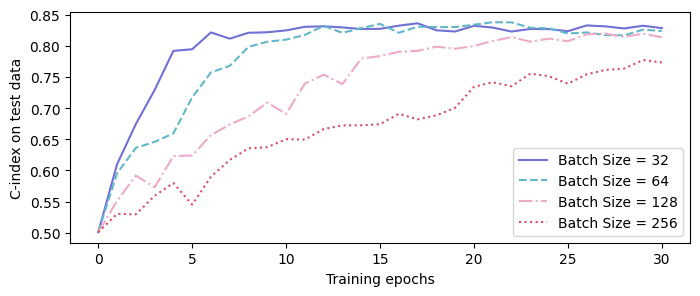

In [155]:
plt.figure(figsize=(8, 3))
plt.ylabel('C-index on test data')
plt.xlabel('Training epochs')
plt.plot(fit_lr002_s32.epoch_cindex,ls = '-', label='Batch Size = 32', color="#7070D5")
plt.plot(fit_lr002_s64.epoch_cindex,ls = '--', label='Batch Size = 64', color="#61B8C9")
plt.plot(fit_lr002_s128.epoch_cindex,ls = '-.', label='Batch Size = 128', color="#EFAAC7")
plt.plot(fit_lr002_s256.epoch_cindex,ls = ':', label='Batch Size = 256', color="#d94c66")
plt.legend()
plt.show
plt.savefig('Figure/AREDS_CoxSNN_batchsizes.png',bbox_inches='tight', dpi=300)

In [9]:
fit_lr002_s4 = Train_CoxSNN_32node(num_lr = 0.002,num_dr = 0.3,num_epoch = 30,batch_size = 4,device = device,freeze_resnet50 = False)
fit_lr002_s4.fit()
torch.cuda.empty_cache()

[  1/  30] loss: 0.20025 val_loss:  1.28645 c-index:  0.78148 time: 11.65308 seconds
[  2/  30] loss: 0.14029 val_loss:  1.29188 c-index:  0.82059 time: 11.38228 seconds
[  3/  30] loss: 0.12209 val_loss:  1.22365 c-index:  0.84325 time: 11.51727 seconds
[  4/  30] loss: 0.11625 val_loss:  1.22850 c-index:  0.84854 time: 11.51184 seconds
[  5/  30] loss: 0.10982 val_loss:  1.23283 c-index:  0.83987 time: 11.43038 seconds
[  6/  30] loss: 0.10742 val_loss:  1.23135 c-index:  0.84861 time: 11.56504 seconds
[  7/  30] loss: 0.10320 val_loss:  1.25001 c-index:  0.83403 time: 11.49822 seconds
[  8/  30] loss: 0.10114 val_loss:  1.23527 c-index:  0.84570 time: 11.36992 seconds
[  9/  30] loss: 0.09659 val_loss:  1.27227 c-index:  0.84489 time: 11.49092 seconds
[ 10/  30] loss: 0.08793 val_loss:  1.22705 c-index:  0.85365 time: 11.46189 seconds
[ 11/  30] loss: 0.09395 val_loss:  1.24087 c-index:  0.83693 time: 11.44942 seconds
[ 12/  30] loss: 0.09168 val_loss:  1.24522 c-index:  0.84304 tim

In [10]:
fit_lr004_s8 = Train_CoxSNN_32node(num_lr = 0.004,num_dr = 0.3,num_epoch = 30,batch_size = 8,device = device,freeze_resnet50 = False)
fit_lr004_s8.fit()
torch.cuda.empty_cache()

[  1/  30] loss: 0.29801 val_loss:  1.29253 c-index:  0.80715 time: 8.50114 seconds
[  2/  30] loss: 0.22809 val_loss:  1.24016 c-index:  0.82965 time: 8.38403 seconds
[  3/  30] loss: 0.20492 val_loss:  1.23895 c-index:  0.83269 time: 8.33827 seconds
[  4/  30] loss: 0.19151 val_loss:  1.24830 c-index:  0.83824 time: 8.35933 seconds
[  5/  30] loss: 0.18128 val_loss:  1.24836 c-index:  0.84344 time: 8.37744 seconds
[  6/  30] loss: 0.17172 val_loss:  1.27851 c-index:  0.84170 time: 8.44599 seconds
[  7/  30] loss: 0.16065 val_loss:  1.25902 c-index:  0.83609 time: 8.40196 seconds
[  8/  30] loss: 0.16039 val_loss:  1.26243 c-index:  0.84064 time: 8.29335 seconds
[  9/  30] loss: 0.14436 val_loss:  1.34169 c-index:  0.82799 time: 8.39240 seconds
[ 10/  30] loss: 0.13376 val_loss:  1.26500 c-index:  0.83687 time: 8.47132 seconds
[ 11/  30] loss: 0.13334 val_loss:  1.35823 c-index:  0.82210 time: 8.32402 seconds
[ 12/  30] loss: 0.12333 val_loss:  1.29015 c-index:  0.83683 time: 8.30959 

In [11]:
fit_lr04_s8 = Train_CoxSNN_32node(num_lr = 0.04,num_dr = 0.3,num_epoch = 30,batch_size = 8,device = device,freeze_resnet50 = False)
fit_lr04_s8.fit()
torch.cuda.empty_cache()

[  1/  30] loss: 0.25724 val_loss:  1.37958 c-index:  0.81606 time: 8.38765 seconds
[  2/  30] loss: 0.21874 val_loss:  1.24200 c-index:  0.83499 time: 8.35269 seconds
[  3/  30] loss: 0.19580 val_loss:  1.21322 c-index:  0.84530 time: 8.31888 seconds
[  4/  30] loss: 0.18357 val_loss:  1.25128 c-index:  0.83493 time: 8.36974 seconds
[  5/  30] loss: 0.17368 val_loss:  1.26726 c-index:  0.81836 time: 8.39139 seconds
[  6/  30] loss: 0.16488 val_loss:  1.22656 c-index:  0.84937 time: 8.43359 seconds
[  7/  30] loss: 0.15257 val_loss:  1.25123 c-index:  0.84293 time: 8.37503 seconds
[  8/  30] loss: 0.14512 val_loss:  1.27799 c-index:  0.84577 time: 8.27474 seconds
[  9/  30] loss: 0.14032 val_loss:  1.28632 c-index:  0.83047 time: 8.39030 seconds
[ 10/  30] loss: 0.12854 val_loss:  1.29859 c-index:  0.84778 time: 8.45046 seconds
[ 11/  30] loss: 0.13356 val_loss:  1.31695 c-index:  0.83642 time: 8.32527 seconds
[ 12/  30] loss: 0.11465 val_loss:  1.27213 c-index:  0.84480 time: 8.30108 

In [23]:
fit_lr4_s8 = Train_CoxSNN_32node(num_lr = 0.4,num_dr = 0.3,num_epoch = 30,batch_size = 8,device = device,freeze_resnet50 = False)
fit_lr4_s8.fit()
torch.cuda.empty_cache()

[  1/  30] loss: 0.37307 val_loss:  1.39392 c-index:  0.55949 time: 8.38581 seconds
[  2/  30] loss: 0.35315 val_loss:  1.40209 c-index:  0.52698 time: 8.34293 seconds
[  3/  30] loss: 0.34838 val_loss:  1.51473 c-index:  0.60175 time: 8.31201 seconds
[  4/  30] loss: 0.34848 val_loss:  1.38877 c-index:  0.60013 time: 8.37453 seconds
[  5/  30] loss: 0.34159 val_loss:  1.37888 c-index:  0.63631 time: 8.37215 seconds
[  6/  30] loss: 0.34503 val_loss:  1.38245 c-index:  0.64763 time: 8.43955 seconds
[  7/  30] loss: 0.35087 val_loss:  1.37976 c-index:  0.64050 time: 8.37952 seconds
[  8/  30] loss: 0.34420 val_loss:  1.35667 c-index:  0.69054 time: 8.27748 seconds
[  9/  30] loss: 0.34114 val_loss:  1.36934 c-index:  0.67801 time: 8.37957 seconds
[ 10/  30] loss: 0.33453 val_loss:  1.36986 c-index:  0.65147 time: 8.43029 seconds
[ 11/  30] loss: 0.33411 val_loss:  1.35391 c-index:  0.68742 time: 8.30749 seconds
[ 12/  30] loss: 0.32904 val_loss:  1.35089 c-index:  0.69703 time: 8.30365 

In [21]:
gpu_memory = {'32':3.50, '64':6.80, '128':13.5, '256':26.9}
batches = list(gpu_memory.keys())
values_gpu = list(gpu_memory.values())

epoch_time = {'32':9.50, '64':11.0, '128':12.1, '256':12.7}
batches = list(epoch_time.keys())
values_time = list(epoch_time.values()) 

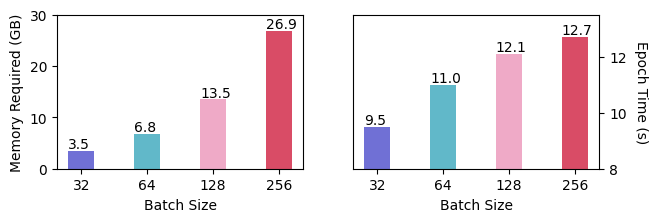

In [22]:
width = 0.4
colors = ["#7070D5","#61B8C9","#EFAAC7","#d94c66"]
fig, [ax1,ax2] = plt.subplots(1, 2,figsize=(7, 2))
ax1.bar(batches, values_gpu, width = 0.4,color=colors)
ax1.set_ylabel("Memory Required (GB)")
ax1.set_xlabel("Batch Size")

xlocs = ax1.get_xticks()
ax1.set_ylim(0,30 )
for i, v in enumerate(values_gpu):
    ax1.text(xlocs[i]-width/2 , v+0.5, str("{:.1f}".format(v)))
    
ax2.bar(batches, values_time,color=colors, 
        width = 0.4)
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
ax2.set_ylim(8,13.5 )
ax2.set_ylabel("Epoch Time (s)",rotation=-90,labelpad=15)
ax2.set_ylabel("Epoch Time (s)",rotation=-90,labelpad=15)
ax2.set_xlabel("Batch Size")

xlocs = ax2.get_xticks()
for i, v in enumerate(values_time):
    ax2.text(xlocs[i]-width/2 , v+0.1, str("{:.1f}".format(v)))

plt.savefig('Figure/AREDS_batchsizes_memorytimes.png',bbox_inches='tight', dpi=300)